# White Hat vs Black Hat Visualizations
**Project:** Airbnb & Long-Term Rental Dynamics in Milan  
**Data sources:** Airbnb Inside Milan (`listings_milan_clean.csv`) · OMI rental quotations 2018–2024  

This notebook produces two static figures from the **same real data**:
- `Output/white_hat.png` — honest, transparent, contextualized
- `Output/black_hat.png` — manipulated to exaggerate causation

In [1]:
#  IMPORTS and OUTPUT FOLDER 
import pandas as pd
import matplotlib.pyplot as plt
import glob, os
from pathlib import Path

Path('../Output').mkdir(exist_ok=True)
print('Ready.')

Ready.


In [2]:
# LOAD AIRBNB DATA 
listings = pd.read_csv('../Data/listings_milan_clean.csv')
listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')
listings['year'] = listings['last_review'].dt.year

airbnb_per_year = (
    listings[listings['year'].between(2018, 2024)]
    .groupby('year')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'active_listings'})
)
airbnb_per_year['year'] = airbnb_per_year['year'].astype(int)
print(airbnb_per_year)

   year  active_listings
0  2018               36
1  2019               75
2  2020               50
3  2021               93
4  2022              385
5  2023              704
6  2024             2018


In [3]:
#  LOAD OMI DATA 
files = glob.glob('../Data/quotazioni_omi_locazione_*.csv')

dfs = []
for f in files:
    name = os.path.basename(f)
    year = int(name.split('_')[-2])

    # Some files (e.g. 2023) have a metadata row before the real header;
    # others start directly with the column names.
    with open(f, encoding='latin1') as fh:
        first_line = fh.readline()
    skip = 1 if 'Area_territoriale' not in first_line else 0

    df = pd.read_csv(f, sep=';', encoding='latin1', skiprows=skip, decimal=',')
    df['year'] = year
    dfs.append(df)

omi = pd.concat(dfs, ignore_index=True)

# Filter: Milan only + residential types only
residential_types = ['Abitazioni civili', 'Abitazioni di tipo economico', 'Abitazioni signorili']
omi_milan = omi[
    (omi['Comune_descrizione'] == 'MILANO') &
    (omi['Descr_Tipologia'].isin(residential_types))
].copy()

omi_milan['Loc_min'] = pd.to_numeric(omi_milan['Loc_min'], errors='coerce')
omi_milan['Loc_max'] = pd.to_numeric(omi_milan['Loc_max'], errors='coerce')
omi_milan['rent_mid'] = (omi_milan['Loc_min'] + omi_milan['Loc_max']) / 2

omi_per_year = (
    omi_milan.groupby('year')['rent_mid']
    .mean()
    .round(2)
    .reset_index()
)
omi_per_year = omi_per_year[omi_per_year['year'].between(2018, 2024)]
print(omi_per_year)

   year  rent_mid
0  2018     12.08
1  2019     12.26
2  2020     12.46
3  2021     12.46
4  2022     13.21
5  2023     14.60
6  2024     16.14


In [4]:
#  MERGE INTO ONE TABLE 
data = pd.merge(airbnb_per_year, omi_per_year, on='year')
print(data)

# Shorthand for plots
years          = data['year'].tolist()
airbnb_listings = data['active_listings'].tolist()
avg_rent        = data['rent_mid'].tolist()

   year  active_listings  rent_mid
0  2018               36     12.08
1  2019               75     12.26
2  2020               50     12.46
3  2021               93     12.46
4  2022              385     13.21
5  2023              704     14.60
6  2024             2018     16.14


## WHITE HAT
**What makes it honest:**
1. Y-axes start at **zero** — no visual inflation
2. Both axes clearly **labelled with units**
3. **COVID band** contextualises the 2020 shock
4. **Neutral title** — describes, does not conclude
5. **Sources cited** at the bottom
6. Subtitle reminds that **correlation ≠ causation**

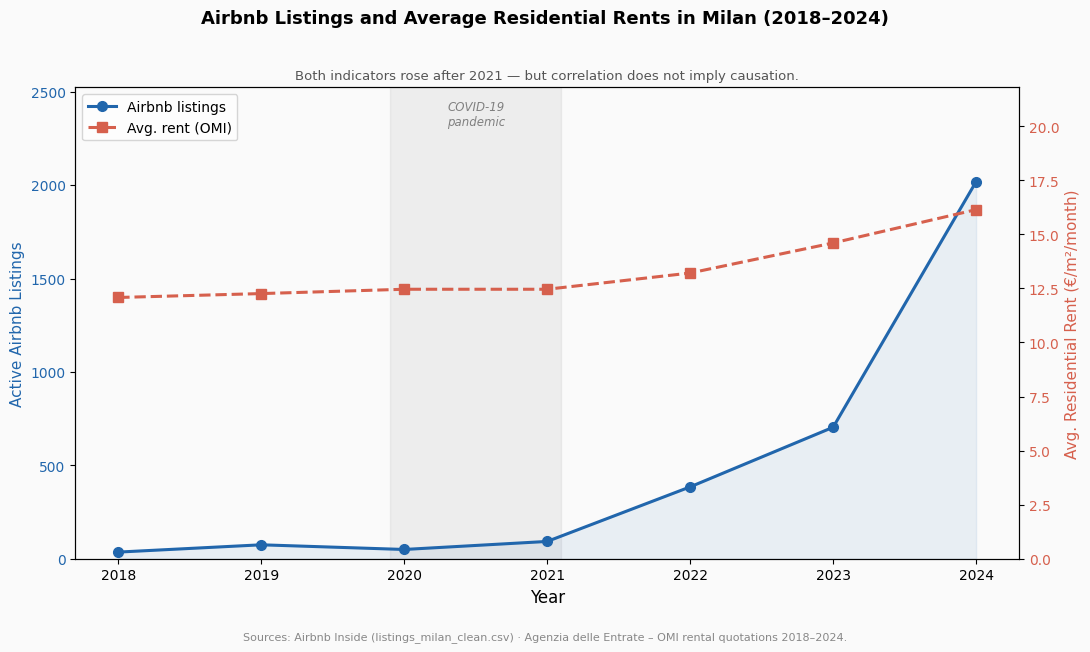

Saved → Output/white_hat.png


In [5]:
fig, ax1 = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#fafafa')
ax1.set_facecolor('#fafafa')

#  Airbnb line (left axis) 
c_airbnb = '#2166ac'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Active Airbnb Listings', color=c_airbnb, fontsize=11)
ax1.plot(years, airbnb_listings, color=c_airbnb, marker='o',
         linewidth=2.2, markersize=7, label='Airbnb listings')
ax1.fill_between(years, airbnb_listings, alpha=0.08, color=c_airbnb)
ax1.tick_params(axis='y', labelcolor=c_airbnb)
ax1.set_ylim(0, max(airbnb_listings) * 1.25)   # starts at ZERO
ax1.set_xticks(years)

#  Rent line (right axis) 
c_rent = '#d6604d'
ax2 = ax1.twinx()
ax2.set_ylabel('Avg. Residential Rent (€/m²/month)', color=c_rent, fontsize=11)
ax2.plot(years, avg_rent, color=c_rent, marker='s', linestyle='--',
         linewidth=2.2, markersize=7, label='Avg. rent (OMI)')
ax2.tick_params(axis='y', labelcolor=c_rent)
ax2.set_ylim(0, max(avg_rent) * 1.35)           # starts at ZERO

#  COVID band               
ax1.axvspan(2019.9, 2021.1, alpha=0.10, color='grey', zorder=0)
ax1.text(
    2020.5, max(airbnb_listings) * 1.15,
    'COVID-19\npandemic', ha='center', fontsize=8.5,
    color='grey', style='italic'
)

#  Titles 
fig.suptitle(
    'Airbnb Listings and Average Residential Rents in Milan (2018–2024)',
    fontsize=13, fontweight='bold', y=1.02
)
ax1.set_title(
    'Both indicators rose after 2021 — but correlation does not imply causation.',
    fontsize=9.5, color='#555555', pad=6
)

#  Legend 
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=10)

#  Source note 
fig.text(
    0.5, -0.03,
    'Sources: Airbnb Inside (listings_milan_clean.csv) · Agenzia delle Entrate – OMI rental quotations 2018–2024.',
    ha='center', fontsize=8, color='#888888'
)

fig.tight_layout()
fig.savefig('../Output/white_hat.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → Output/white_hat.png')

## BLACK HAT
**Same data — manipulated to mislead:**

| Technique | Why it deceives |
|---|---|
| **Truncated Y-axes** | Small real rise looks like a cliff |
| **COVID band removed** | Rebound looks Airbnb-driven, not pandemic-driven |
| **Causal title** | Presents correlation as proven fact |
| **Red palette on dark background** | Triggers alarm/threat response |
| **No source citation** | Prevents verification |
| **Arrow annotation** | Anchors a dramatic narrative |

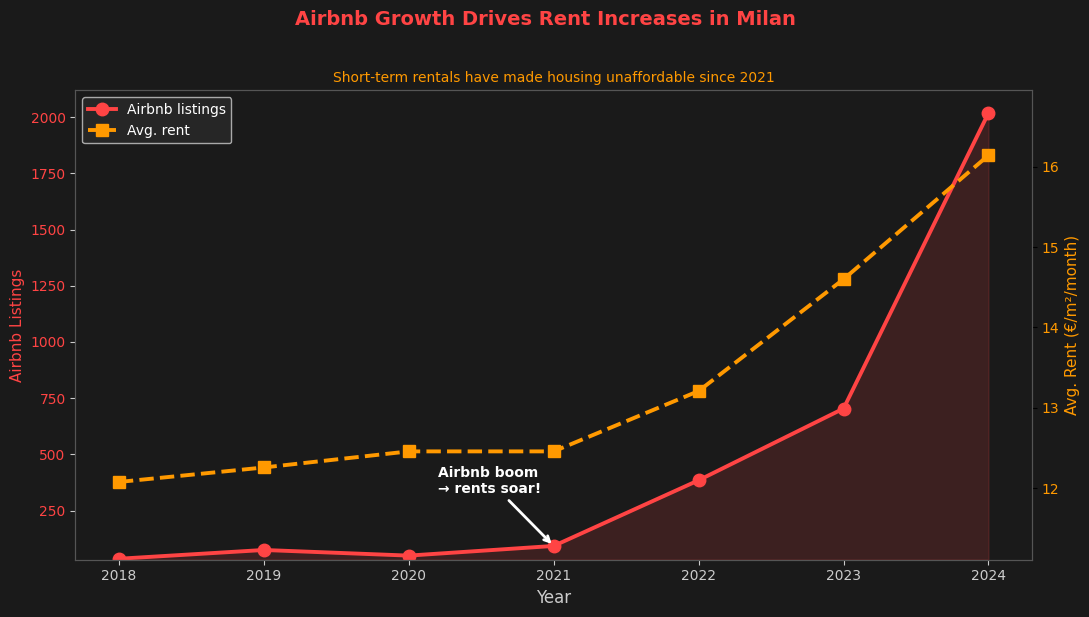

Saved → Output/black_hat.png


In [6]:
fig, ax1 = plt.subplots(figsize=(11, 6), facecolor='#1a1a1a')
ax1.set_facecolor('#1a1a1a')

c_ab  = '#ff4444'
c_rnt = '#ff9900'
sc    = '#555555'

for spine in ax1.spines.values():
    spine.set_edgecolor(sc)
ax1.tick_params(colors='#cccccc')
ax1.set_xlabel('Year', fontsize=12, color='#cccccc')
ax1.set_ylabel('Airbnb Listings', color=c_ab, fontsize=11)
ax1.plot(years, airbnb_listings, color=c_ab, marker='o',
         linewidth=2.8, markersize=9, label='Airbnb listings')
ax1.fill_between(years, airbnb_listings, min(airbnb_listings)*0.9,
                 alpha=0.15, color=c_ab)
ax1.tick_params(axis='y', labelcolor=c_ab)

# TRUNCATED axis — does NOT start at zero
y_min_ab = min(airbnb_listings) * 0.88
ax1.set_ylim(y_min_ab, max(airbnb_listings) * 1.05)
ax1.set_xticks(years)
ax1.tick_params(axis='x', colors='#cccccc')

ax2 = ax1.twinx()
ax2.set_facecolor('#1a1a1a')
for spine in ax2.spines.values():
    spine.set_edgecolor(sc)
ax2.set_ylabel('Avg. Rent (€/m²/month)', color=c_rnt, fontsize=11)
ax2.plot(years, avg_rent, color=c_rnt, marker='s', linestyle='--',
         linewidth=2.8, markersize=9, label='Avg. rent')
ax2.tick_params(axis='y', labelcolor=c_rnt)

# TRUNCATED axis — does NOT start at zero
y_min_rnt = min(avg_rent) * 0.92
ax2.set_ylim(y_min_rnt, max(avg_rent) * 1.05)

# Arrow annotation — dramatises post-2021
mid_year = years[len(years)//2]
mid_ab   = airbnb_listings[len(years)//2]
ax1.annotate(
    'Airbnb boom\n→ rents soar!',
    xy=(mid_year, mid_ab),
    xytext=(mid_year - 0.8, y_min_ab + (max(airbnb_listings)-y_min_ab)*0.15),
    arrowprops=dict(arrowstyle='->', color='white', lw=2),
    fontsize=10, color='white', fontweight='bold'
)

# Causal, alarming title — no nuance
fig.suptitle(
    'Airbnb Growth Drives Rent Increases in Milan',
    fontsize=14, fontweight='bold', color='#ff4444', y=1.02
)
ax1.set_title(
    'Short-term rentals have made housing unaffordable since 2021',
    fontsize=10, color='#ff9900', pad=6
)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left',
           fontsize=10, facecolor='#2a2a2a', labelcolor='white')

# NO source citation

fig.tight_layout()
fig.savefig('../Output/black_hat.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → Output/black_hat.png')